--- نتایج شبکه هب برای گیت AND ---
وزن‌های نهایی: Bias (w0) = -2.0, w1 = 2.0, w2 = 2.0
تست شبکه (پیش‌بینی‌ها):
Input: [1 1] | Target: 1 | Prediction: 1 | ✓
Input: [ 1 -1] | Target: -1 | Prediction: -1 | ✓
Input: [-1  1] | Target: -1 | Prediction: -1 | ✓
Input: [-1 -1] | Target: -1 | Prediction: -1 | ✓
----------------------------------------


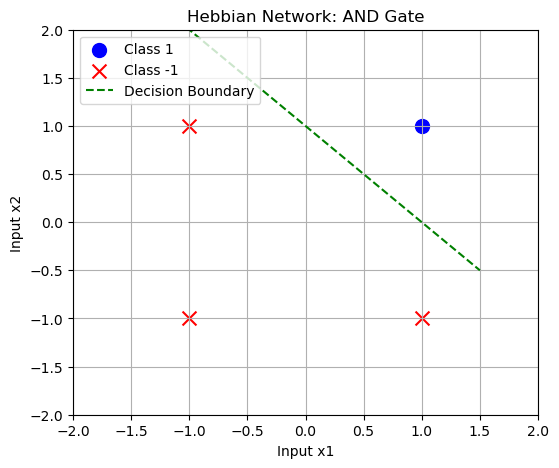

--- نتایج شبکه هب برای گیت OR ---
وزن‌های نهایی: Bias (w0) = 2.0, w1 = 2.0, w2 = 2.0
تست شبکه (پیش‌بینی‌ها):
Input: [1 1] | Target: 1 | Prediction: 1 | ✓
Input: [ 1 -1] | Target: 1 | Prediction: 1 | ✓
Input: [-1  1] | Target: 1 | Prediction: 1 | ✓
Input: [-1 -1] | Target: -1 | Prediction: -1 | ✓
----------------------------------------


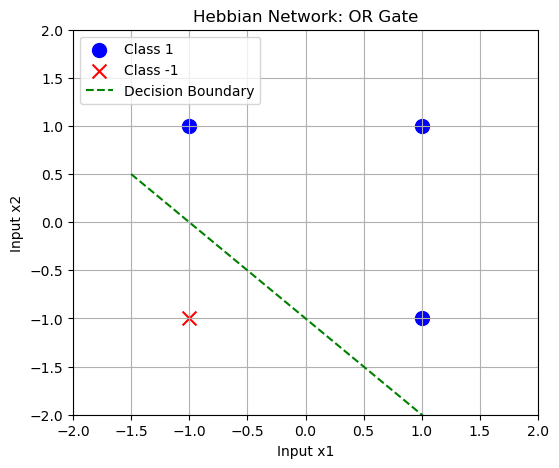

--- نتایج شبکه هب برای گیت XOR ---
وزن‌های نهایی: Bias (w0) = 0.0, w1 = 0.0, w2 = 0.0
تست شبکه (پیش‌بینی‌ها):
Input: [1 1] | Target: -1 | Prediction: 1 | ✗ (خطا)
Input: [ 1 -1] | Target: 1 | Prediction: 1 | ✓
Input: [-1  1] | Target: 1 | Prediction: 1 | ✓
Input: [-1 -1] | Target: -1 | Prediction: 1 | ✗ (خطا)
----------------------------------------


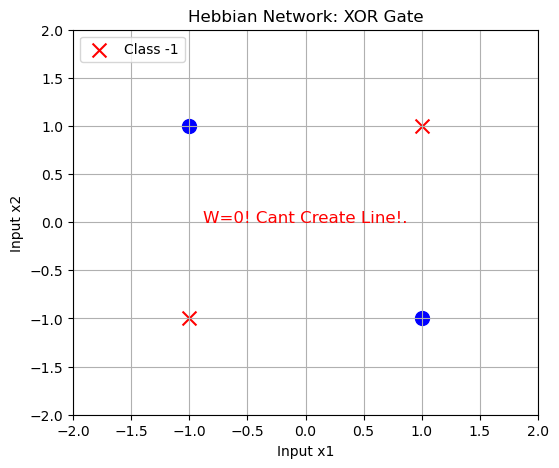

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def hebbian_learning(X, Y, gate_name):
    # 1 مقداردهی اولیه
    w = np.zeros(X.shape[1])
    
    # 2 آموزش هب
    for i in range(len(X)):
        x_i = X[i]
        y_i = Y[i]
        delta_w = x_i * y_i
        # w_new = w_old + delta_w
        w = w + delta_w
        
    print(f"--- نتایج شبکه هب برای گیت {gate_name} ---")
    print(f"وزن‌های نهایی: Bias (w0) = {w[0]}, w1 = {w[1]}, w2 = {w[2]}")
    
    # 3 تست شبکه 
    print("تست شبکه (پیش‌بینی‌ها):")
    for i in range(len(X)):
        # NET = w0*1 + w1*x1 + w2*x2
        net_input = np.dot(X[i], w)
        # تابع فعال‌ساز
        prediction = 1 if net_input >= 0 else -1

        x_disp = X[i][1:] # حذف عدد 1 مربوط به بایاس برای نمایش
        y_disp = Y[i]
        p_disp = prediction
        
        print(f"Input: {x_disp} | Target: {y_disp} | Prediction: {p_disp} | {'✓' if y_disp == p_disp else '✗ (خطا)'}")
    print("-" * 40)
    
    # 4. رسم نمودار
    plot_decision_boundary(X, Y, w, gate_name)

def plot_decision_boundary(X, Y, w, gate_name):
    plt.figure(figsize=(6, 5))
    
    # (-1 = آبی = 1 و قرمز)
    for i in range(len(X)):
        if Y[i] == 1:
            plt.scatter(X[i, 1], X[i, 2], color='blue', marker='o', s=100, label='Class 1' if i==0 else "")
        else:
            plt.scatter(X[i, 1], X[i, 2], color='red', marker='x', s=100, label='Class -1' if i==3 else "")

    # معادله خط: w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w1/w2)*x1 - (w0/w2)
    if abs(w[2]) > 1e-6: 
        x1_vals = np.array([-1.5, 1.5])
        x2_vals = -(w[1] / w[2]) * x1_vals - (w[0] / w[2])
        plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision Boundary')
    elif w[1] == 0 and w[2] == 0:
        plt.text(0, 0, "W=0! Cant Create Line!.", color='red', ha='center', fontsize=12)

    plt.title(f"Hebbian Network: {gate_name} Gate")
    plt.xlabel("Input x1")
    plt.ylabel("Input x2")
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.grid(True)
    
    # جلوگیری از تکرار لیبل‌ها در Legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.show()

#################################

# ============== Input ==============
X_bipolar = np.array([
    [1,  1,  1],  # 1, 1
    [1,  1, -1],  # 1, 0
    [1, -1,  1],  # 0, 1
    [1, -1, -1]   # 0, 0
])

# ============== Target ==============
Y_AND = np.array([ 1, -1, -1, -1])
Y_OR  = np.array([ 1,  1,  1, -1])
Y_XOR = np.array([-1,  1,  1, -1])

# ============== RUN ==============

hebbian_learning(X_bipolar, Y_AND, "AND")
hebbian_learning(X_bipolar, Y_OR, "OR")
hebbian_learning(X_bipolar, Y_XOR, "XOR")
